# MC-DCNN over the full TS
- Use ROC-AUC as metric.

In [1]:
import os
# Make sure XLA is OFF (Metal doesn't support XLA/JIT)
# os.environ.pop("TF_XLA_FLAGS", None)
# os.environ.pop("XLA_FLAGS", None)
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"


import tensorflow as tf
# print("JIT actually off? ->", tf.config.optimizer.get_jit())  # should be False
# tf.debugging.set_log_device_placement(True)  
# tf.config.optimizer.set_jit(False)
# print("GPUs:", tf.config.list_physical_devices("GPU"))


import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score
)

import kineticstoolkit as ktk

import random
import pickle
import json
from typing import Tuple

from tensorflow import keras
import keras_tuner as kt
from tensorflow.keras import layers as L, models as M, Input, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy

from core.matlab_data_loader import MatlabDataLoader
from core.processing import preprocess_features
from core.timeseries import plot_compare_features, plot_all_features_overlay, bilateral_to_unilateral, split_unilateral
from core.evaluation import model_test_summary, BilateralSingleInputPredictor, pick_threshold
from core.tunning import MetaHyperModel, ModelLoader, summarize_best_N_models


from pathlib import Path
import core.constants as c

RANDOM_STATE = 42
RANDOM_STATE_2 = 6
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Optimization for M4
from tensorflow.keras import mixed_precision
#  mixed_precision.set_global_policy("mixed_float16")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [2]:
# Did I accidentally import standalone keras?
import keras
print("Standalone keras file:", keras.__file__)  # should live under your TF install if using tf.keras via KERAS_BACKEND

# Is JIT actually off?
print("JIT enabled?", tf.config.optimizer.get_jit())


Standalone keras file: /Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/__init__.py
JIT enabled? 


## Notebook configuration

- **SAVE_MODEL**  
  - `True`: Will run and save this iteration of the model.  
  - `False`: Will load the model from the results folder.

- **SAVE_DATA**  
  - `True`: Will save the train, test, and validation sets as npz files.  
  - `False`: Will load the data from the results folder.

- **USE_TENSORBOARD**  
  - `True`: Will use TensorBoard to visualize the training process.
  - `False`: Will not use TensorBoard.

- **MODEL_NAME**  
  - The name of the model.

- **MODEL_RESULTS_FOLDER**  
  - The folder where the model results will be saved.

In [3]:
MODEL_NAME = "roc-mc-dcnn-v1"
MODEL_RESULTS_FOLDER = Path(c.RICKD_MODELS_FOLDER)/ "deep_learning" / MODEL_NAME
MODEL_RESULTS_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Model results folder: {MODEL_RESULTS_FOLDER}")

Model results folder: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1


In [33]:
SAVE_MODEL = False
SAVE_DATA = False
USE_TENSORBOARD = True

print(f"SAVE_MODEL: {SAVE_MODEL}")
print(f"SAVE_DATA: {SAVE_DATA}")
print(f"USE_TENSORBOARD: {USE_TENSORBOARD}")

SAVE_MODEL: False
SAVE_DATA: False
USE_TENSORBOARD: True


## Load Input Data

In [5]:
timeseries_folder = Path(c.RICKD_PROCESSED_DATA_FOLDER) / 'timeseries'

all_sessions_matrix = np.load(timeseries_folder / 'timeseries_mean_matrix.npy')
with open(timeseries_folder / 'timeseries_mean_channels.json', 'r') as f:
    channels = json.load(f)
with open(timeseries_folder / 'timeseries_mean_sessions.json', 'r') as f:
    valid_session_ids = json.load(f)

print("Shape of the timeseries matrix: ", all_sessions_matrix.shape)
print("Number of channels: ", len(channels))
print("Number of sessions: ", len(valid_session_ids))

for channel in channels:
    print(channel)

Shape of the timeseries matrix:  (1813, 101, 60)
Number of channels:  60
Number of sessions:  1813
L_ankle_angle_X
L_ankle_angle_Y
L_ankle_angle_Z
L_ankle_velocity_X
L_ankle_velocity_Y
L_ankle_velocity_Z
L_foot_angle_X
L_foot_angle_Y
L_foot_angle_Z
L_foot_velocity_X
L_foot_velocity_Y
L_foot_velocity_Z
L_hip_angle_X
L_hip_angle_Y
L_hip_angle_Z
L_hip_velocity_X
L_hip_velocity_Y
L_hip_velocity_Z
L_knee_angle_X
L_knee_angle_Y
L_knee_angle_Z
L_knee_velocity_X
L_knee_velocity_Y
L_knee_velocity_Z
R_ankle_angle_X
R_ankle_angle_Y
R_ankle_angle_Z
R_ankle_velocity_X
R_ankle_velocity_Y
R_ankle_velocity_Z
R_foot_angle_X
R_foot_angle_Y
R_foot_angle_Z
R_foot_velocity_X
R_foot_velocity_Y
R_foot_velocity_Z
R_hip_angle_X
R_hip_angle_Y
R_hip_angle_Z
R_hip_velocity_X
R_hip_velocity_Y
R_hip_velocity_Z
R_knee_angle_X
R_knee_angle_Y
R_knee_angle_Z
R_knee_velocity_X
R_knee_velocity_Y
R_knee_velocity_Z
L_pelvis_angle_X
L_pelvis_angle_Y
L_pelvis_angle_Z
L_pelvis_velocity_X
L_pelvis_velocity_Y
L_pelvis_velocity_

In [6]:
loader = MatlabDataLoader()

session_data = loader.get_session_data_full_cleaned().set_index("id")
metadata_columns = ["age", "Height", "Weight", "Gender", "DominantLeg", "speed_r"]
metadata = session_data[metadata_columns]
complete_metadata = metadata.dropna()

num_complete_rows = complete_metadata.shape[0]
print(f"\nNumber of rows with a value for all metadata columns: {num_complete_rows}")
complete_metadata.info(verbose=True)



Number of rows with a value for all metadata columns: 1476
<class 'pandas.core.frame.DataFrame'>
Index: 1476 entries, 100560_20120717T103748 to 201099_20150414T092041
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          1476 non-null   float64
 1   Height       1476 non-null   float64
 2   Weight       1476 non-null   float64
 3   Gender       1476 non-null   object 
 4   DominantLeg  1476 non-null   object 
 5   speed_r      1476 non-null   float64
dtypes: float64(4), object(2)
memory usage: 80.7+ KB


In [7]:
# Compare valid_session_ids against sessions with complete metadata
session_ids = set(session_data.index.astype(str))
valid_ids = set(map(str, valid_session_ids))
intersection_ids = valid_ids & session_ids
complete_ids = set(complete_metadata.index.astype(str))
complete_intersection_ids = complete_ids & valid_ids

print(f"Number of sessions: {len(session_ids)}")
print(f"Number of time-series sessions: {len(valid_ids)}")
print(f"Number of sessions with complete metadata: {len(complete_ids)}")
print(f"Number of sessions present both in metadata and time-series: {len(intersection_ids)}")
print(f"Number of sessions with complete metadata and present in time-series: {len(complete_intersection_ids)}")
print(f"We loose {(1-(len(complete_intersection_ids) / len(valid_ids)))*100:.2f}% of the data due to missing metadata.")

Number of sessions: 1832
Number of time-series sessions: 1813
Number of sessions with complete metadata: 1476
Number of sessions present both in metadata and time-series: 1812
Number of sessions with complete metadata and present in time-series: 1456
We loose 19.69% of the data due to missing metadata.


In [8]:
filtered_indices = [i for i, sid in enumerate(intersection_ids)]
metadata_common = complete_metadata.loc[list(complete_intersection_ids)]

In [9]:
# N = 1813 -- Sessions
X_ts: np.ndarray = all_sessions_matrix[filtered_indices]  #  (N, 101, 54)
y: pd.Series = session_data.loc[list(intersection_ids), "is_injured"]  # (N,)
subject_id: pd.Series = session_data.loc[list(intersection_ids), "sub_id"]   # (N,)
print("X_ts.shape: ", X_ts.shape)
print("y.shape: ", y.shape)
print("subject_id.shape: ", subject_id.shape)

X_ts.shape:  (1812, 101, 60)
y.shape:  (1812,)
subject_id.shape:  (1812,)


## Preprocessing of input data
- Scale with Z-Score & one-hot encode categorical cols
- Split data into train, validation and test sets

In [10]:
# Handle metadata preprocessing (one-hot encoding for categorical variables)
print("Preprocessing of Metadata")
print("="*50)
print("Original metadata columns:", metadata_common.columns.tolist())
print("Original metadata shape:", metadata_common.shape)

# Scale with Z-Score & one-hot encode categorical cols
X_meta_scaled_df, scaler_meta = preprocess_features(metadata_common, y, feature_categorical_columns=['Gender', 'DominantLeg'], return_scaler=True)
X_meta_scaled = X_meta_scaled_df.values.astype(np.float32)
meta_feature_names = X_meta_scaled_df.columns.tolist()

print(f"Final metadata shape: {X_meta_scaled.shape}")
print(f"Feature names: {meta_feature_names}")


Preprocessing of Metadata
Original metadata columns: ['age', 'Height', 'Weight', 'Gender', 'DominantLeg', 'speed_r']
Original metadata shape: (1456, 6)
Final metadata shape: (1456, 8)
Feature names: ['age', 'Height', 'Weight', 'speed_r', 'Gender_male', 'DominantLeg_ambidextrous', 'DominantLeg_left', 'DominantLeg_right']


In [11]:
# Step 1: Data Exploration and Preprocessing
print("Data overview")
print("="*50)
print(f"Timeseries shape: {X_ts.shape}")  # (N, 101, 48)
print(f"Metadata shape: {X_meta_scaled.shape}")  # (N, metadata_features)
print(f"Labels shape: {y.shape}")        # (N,)
print(f"Subject IDs shape: {subject_id.shape}")  # (N,)

# Check class distribution
unique, counts = np.unique(y, return_counts=True)
print(f"\nClass distribution:")
for label, count in zip(unique, counts):
    print(f"  Class {int(label)}: {count} samples ({count/len(y)*100:.1f}%)")

# Check for any missing values
print(f"\nMissing values in timeseries: {np.isnan(X_ts).sum()}")
print(f"Missing values in metadata: {np.isnan(X_meta_scaled).sum()}")


Data overview
Timeseries shape: (1812, 101, 60)
Metadata shape: (1456, 8)
Labels shape: (1812,)
Subject IDs shape: (1812,)

Class distribution:
  Class 0: 662 samples (36.5%)
  Class 1: 1150 samples (63.5%)

Missing values in timeseries: 0
Missing values in metadata: 0


In [12]:
print("Preprocessing of Timeseries")
print("="*50)

print(f"Timeseries stats:")
print(f"  Min: {X_ts.min():.3f}, Max: {X_ts.max():.3f}")
print(f"  Mean: {X_ts.mean():.3f}, Std: {X_ts.std():.3f}")

# Reshape for scaling: (N*101, 48) -> scale -> reshape back to (N, 101, 48)
N, T, C = X_ts.shape
X_ts_reshaped = X_ts.reshape(-1, C)
scaler_ts = StandardScaler()
X_ts_scaled = scaler_ts.fit_transform(X_ts_reshaped).reshape(N, T, C).astype(np.float32)

print("")
print(f"Timeseries scaled stats:")
print(f"  Min: {X_ts_scaled.min():.3f}, Max: {X_ts_scaled.max():.3f}")
print(f"  Mean: {X_ts_scaled.mean():.3f}, Std: {X_ts_scaled.std():.3f}")


Preprocessing of Timeseries
Timeseries stats:
  Min: -11792.077, Max: 12357.174
  Mean: -1.214, Std: 103.499

Timeseries scaled stats:
  Min: -101.184, Max: 91.427
  Mean: -0.000, Std: 1.000


In [13]:
def train_test_group_split(
    X_ts, X_meta, y, subject_id, test_size=0.2, random_state=None
):
    """
    Split data into train and test sets or train and validation sets using GroupShuffleSplit to ensure subject-level separation.
    Returns:
        X_ts_train, X_ts_test, X_meta_train, X_meta_test, y_train, y_test, subject_train, subject_test
    """
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(X_ts, y, groups=subject_id))

    # Split the data
    X_ts_train, X_ts_test = X_ts[train_idx], X_ts[test_idx]
    if X_meta is None:
        X_meta_train, X_meta_test = np.empty(X_ts_train.shape), np.empty(X_ts_test.shape)
    y_train, y_test = y[train_idx], y[test_idx]
    subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]

    print(f"Training set: {len(train_idx)} sessions from {len(np.unique(subject_train))} subjects")
    print(f"Test/Validation set: {len(test_idx)} sessions from {len(np.unique(subject_test))} subjects")

    # Verify no subject overlap
    subject_overlap = set(subject_train) & set(subject_test)
    if len(subject_overlap) > 0:
        raise ValueError("Subject overlap found in train-test split!!!")

    # Check class distribution in splits
    train_counts = np.bincount(y_train.astype(int))
    test_counts = np.bincount(y_test.astype(int))
    print(f"\nTrain class distribution: {train_counts} ({np.round(train_counts/len(y_train)*100, 2)}%)")
    print(f"Test/Validation class distribution: {test_counts} ({np.round(test_counts/len(y_test)*100, 2)}%)")

    return (
        X_ts_train, X_ts_test,
        X_meta_train, X_meta_test,
        y_train, y_test,
        subject_train, subject_test
    )

print("Train-Test Split")
print("="*50)
(
    X_ts_train, X_ts_test,
    X_meta_train, X_meta_test,
    y_train, y_test,
    subject_train, subject_test
) = train_test_group_split(X_ts_scaled, None, y, subject_id, test_size=0.2, random_state=RANDOM_STATE)

Train-Test Split
Training set: 1453 sessions from 1114 subjects
Test/Validation set: 359 sessions from 279 subjects

Train class distribution: [515 938] ([35.44 64.56]%)
Test/Validation class distribution: [147 212] ([40.95 59.05]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_71597/2187932121.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_71597/2187932121.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [14]:
# To handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

print(f"Class weights")
print("="*50)
print(f"Class weights: {class_weight_dict}")

Class weights
Class weights: {0: np.float64(1.4106796116504854), 1: np.float64(0.7745202558635395)}


In [15]:
print("Train-Validaton Split")
print("="*50)
(
    X_ts_train_final, X_ts_val,
    X_meta_train_final, X_meta_val,
    y_train_final, y_val,
    subject_train_final, subject_val
) = train_test_group_split(X_ts_train, None, y_train, subject_train, test_size=0.2, random_state=RANDOM_STATE)

Train-Validaton Split
Training set: 1156 sessions from 891 subjects
Test/Validation set: 297 sessions from 223 subjects

Train class distribution: [423 733] ([36.59 63.41]%)
Test/Validation class distribution: [ 92 205] ([30.98 69.02]%)


/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_71597/2187932121.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_train, y_test = y[train_idx], y[test_idx]
/var/folders/2w/vl1bz9zs2c37dzy7d38b9cbm0000gn/T/ipykernel_71597/2187932121.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subject_train, subject_test = subject_id[train_idx], subject_id[test_idx]


In [16]:
print("Fixing data types...")
print("Before:")
print(f"  y_train_final type: {type(y_train_final)}, dtype: {y_train_final.dtype}")
print(f"  y_val type: {type(y_val)}, dtype: {y_val.dtype}")
print(f"  y_test type: {type(y_test)}, dtype: {y_test.dtype}")

# Convert pandas Series to numpy arrays with float32 dtype
y_train_final = y_train_final.values.astype(np.float32)
y_val = y_val.values.astype(np.float32)
y_test = y_test.values.astype(np.float32)

print("\nAfter:")
print(f"  y_train_final type: {type(y_train_final)}, dtype: {y_train_final.dtype}")
print(f"  y_val type: {type(y_val)}, dtype: {y_val.dtype}")
print(f"  y_test type: {type(y_test)}, dtype: {y_test.dtype}")

# Also ensure X data is float32
print(f"\nX data types:")
print(f"  X_ts_train_final dtype: {X_ts_train_final.dtype}")
print(f"  X_ts_val dtype: {X_ts_val.dtype}")
print(f"  X_ts_test dtype: {X_ts_test.dtype}")


Fixing data types...
Before:
  y_train_final type: <class 'pandas.core.series.Series'>, dtype: bool
  y_val type: <class 'pandas.core.series.Series'>, dtype: bool
  y_test type: <class 'pandas.core.series.Series'>, dtype: bool

After:
  y_train_final type: <class 'numpy.ndarray'>, dtype: float32
  y_val type: <class 'numpy.ndarray'>, dtype: float32
  y_test type: <class 'numpy.ndarray'>, dtype: float32

X data types:
  X_ts_train_final dtype: float32
  X_ts_val dtype: float32
  X_ts_test dtype: float32


In [17]:
# Save train, test, and validation sets as npz files (with inverted channels)
if SAVE_DATA:
    print("Saving data to:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "train.npz",
        X_ts=X_ts_train_final,
        X_meta=X_meta_train_final,
        y=y_train_final,
        subject=subject_train_final
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "val.npz",
        X_ts=X_ts_val,
        X_meta=X_meta_val,
        y=y_val,
        subject=subject_val
    )
    np.savez_compressed(
        MODEL_RESULTS_FOLDER / "test.npz",
        X_ts=X_ts_test,
        X_meta=X_meta_test,
        y=y_test,
        subject=subject_test
    )

In [18]:
if not SAVE_DATA:
    print("Loading data from:")
    print("  ", MODEL_RESULTS_FOLDER / "train.npz")
    print("  ", MODEL_RESULTS_FOLDER / "val.npz")
    print("  ", MODEL_RESULTS_FOLDER / "test.npz")
    print()

    train_data = np.load(MODEL_RESULTS_FOLDER / "train.npz")
    val_data   = np.load(MODEL_RESULTS_FOLDER / "val.npz")
    test_data  = np.load(MODEL_RESULTS_FOLDER / "test.npz")

    X_ts_train_final = train_data["X_ts"]
    X_meta_train_final = train_data["X_meta"]
    y_train_final = train_data["y"]
    subject_train_final = train_data["subject"]

    X_ts_val = val_data["X_ts"]
    X_meta_val = val_data["X_meta"]
    y_val = val_data["y"]
    subject_val = val_data["subject"]

    X_ts_test = test_data["X_ts"]
    X_meta_test = test_data["X_meta"]
    y_test = test_data["y"]
    subject_test = test_data["subject"]

print("Train set shapes:")
print("  X_ts_train_final:", X_ts_train_final.shape)
print("  X_meta_train_final:", X_meta_train_final.shape)
print("  y_train_final:", y_train_final.shape)
print("  subject_train_final:", subject_train_final.shape)
print()
print("Validation set shapes:")
print("  X_ts_val:", X_ts_val.shape)
print("  X_meta_val:", X_meta_val.shape)
print("  y_val:", y_val.shape)
print("  subject_val:", subject_val.shape)
print()
print("Test set shapes:")
print("  X_ts_test:", X_ts_test.shape)
print("  X_meta_test:", X_meta_test.shape)
print("  y_test:", y_test.shape)
print("  subject_test:", subject_test.shape)
print()

def class_balance_percent(y):
    counts = np.bincount(y.astype(int))
    total = counts.sum()
    return [f"{100 * c / total:.1f}%" for c in counts]

print("Class balance (train):", class_balance_percent(y_train_final))
print("Class balance (val):", class_balance_percent(y_val))
print("Class balance (test):", class_balance_percent(y_test))

Loading data from:
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/train.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/val.npz
   /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/test.npz



Train set shapes:
  X_ts_train_final: (1156, 101, 60)
  X_meta_train_final: (1156, 101, 60)
  y_train_final: (1156,)
  subject_train_final: (1156,)

Validation set shapes:
  X_ts_val: (297, 101, 60)
  X_meta_val: (297, 101, 60)
  y_val: (297,)
  subject_val: (297,)

Test set shapes:
  X_ts_test: (359, 101, 60)
  X_meta_test: (359, 101, 60)
  y_test: (359,)
  subject_test: (359,)

Class balance (train): ['36.6%', '63.4%']
Class balance (val): ['31.0%', '69.0%']
Class balance (test): ['40.9%', '59.1%']


## Building the model

In [19]:
def build_model(hp: kt.HyperParameters,
                model_name: str,
                features: int = 48,
                time_steps: int = 101,
                clipnorm: float = 1.0):

    # Hyper Parameters
    # Architecture
    activation_combo = hp.Choice(
        "activation_combo", [ "sigmoid_sigmoid", "sigmoid_relu"], # No relu_relu for now...
        default="sigmoid_relu"
    )

    if activation_combo == "sigmoid_sigmoid":
        conv_act, head_act = "sigmoid", "sigmoid"
    elif activation_combo == "sigmoid_relu":
        conv_act, head_act = "sigmoid", "relu"
    elif activation_combo == "relu_relu":
        conv_act, head_act = "relu", "relu"

    # Stage 1
    k1 = hp.Choice("k1", [5, 7], default=5)  # Reduced from [3, 5, 7, 9]
    f1_per_ch = hp.Choice("f1_per_ch", [8, 12], default=8)  # Reduced from [4, 8, 12, 16]
    pool1 = hp.Choice("pool1", [2, 3], default=2)  # Reduced from [2, 3]

    # Stage 2
    k2 = k1  # hp.Choice("k2", [5, 7], default=5)
    f2_per_ch = f1_per_ch  // 2  # hp.Choice("f2_per_ch", [8, 12], default=8)
    pool2 = pool1  # hp.Choice("pool2", [2, 3], default=2)

    # Head
    hidden = hp.Choice("hidden", [256, 512, 768], default=256)  # Reduced from [128, 256, 512, 768]
    fc_dropout = hp.Float("fc_dropout", 0.0, 0.4, step=0.2, default=0.2)  # Reduced from [0.0, 0.5] step 0.1

    # Optimizer
    lr = hp.Float("lr", 2e-4, 4e-4, sampling="log")  # Reduced from [1e-4, 5e-4]
    wd = hp.Float("wd", 1e-5, 1e-4, sampling="log")  # Reduced from [1e-5, 3e-4]

    seq_in = L.Input((time_steps, features))

    # Stage 1: per-channel 1Dconv + BN -> (conv_act) -> avg-pool
    x = L.Conv1D(filters=f1_per_ch * features,
                 kernel_size=k1,
                 padding="same",
                 use_bias=False,  # bias not needed when BN is used
                 groups=features)(seq_in)

    x = L.BatchNormalization(axis=-1)(x)
    x = L.Activation(conv_act)(x)
    x = L.AveragePooling1D(pool_size=pool1, strides=pool1, padding="valid")(x)

    # Stage 1: per-channel 1Dconv + BN -> (conv_act) -> avg-pool
    x = L.Conv1D(filters=f2_per_ch * features,
                 kernel_size=k2,
                 padding="same",
                 use_bias=False,
                 groups=features)(x)

    x = L.BatchNormalization(axis=-1)(x)
    x = L.Activation(conv_act)(x)
    x = L.AveragePooling1D(pool_size=pool2, strides=pool2, padding="valid")(x)

    # Head:
    x = L.Flatten()(x)
    # TODO: Should we use sigmoid? or ReLu?
    # - Sigmoind -> Soft Detector of injury flag duration.
    # - ReLu -> Reduced saturation.
    x = L.Dense(hidden, activation=head_act)(x)
    if fc_dropout > 0.0:
        x = L.Dropout(fc_dropout)(x)

    
    # Output:
    out = L.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = M.Model(seq_in, out, name=model_name)

    opt = tf.keras.optimizers.AdamW(
        learning_rate=lr, weight_decay=wd, global_clipnorm=clipnorm
    )
    model.compile(
        optimizer=opt,
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(curve="PR",  name="auc_pr"),
            tf.keras.metrics.AUC(curve="ROC", name="auc_roc"),
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
        jit_compile=False
    )
    return model


In [20]:
tb_log_dir = Path(MODEL_RESULTS_FOLDER) / "logs"
tb_log_dir.mkdir(parents=True, exist_ok=True)
print(f"TensorBoard log directory: {tb_log_dir}")

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_auc_roc", mode="max",
                                     patience=15, restore_best_weights=True,
                                     min_delta=0.003, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_auc_roc", mode="max",
                                         factor=0.5, patience=5, min_lr=1e-6),
    # Save best model
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(MODEL_RESULTS_FOLDER / f'best_model.h5'),
        monitor='val_auc_roc', mode='max',
        save_best_only=True, verbose=1
    ),
]

if USE_TENSORBOARD:
    callbacks.append(tf.keras.callbacks.TensorBoard(log_dir=tb_log_dir, histogram_freq=1))


TensorBoard log directory: /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/logs


## Training of the model

In [21]:
print("Train set:")
print("X_ts_train_final.shape:", X_ts_train_final.shape)

Train set:
X_ts_train_final.shape: (1156, 101, 60)


In [22]:
print("Validation set:")
print("X_ts_val.shape:", X_ts_val.shape)

Validation set:
X_ts_val.shape: (297, 101, 60)


In [23]:
print("Test set:")
print("X_ts_test.shape:", X_ts_test.shape)

Test set:
X_ts_test.shape: (359, 101, 60)


In [24]:
hyper_model = MetaHyperModel(
    model_name=MODEL_NAME,
    build_model_func=build_model,
    time_steps=X_ts_train_final.shape[1],
    features=X_ts_train_final.shape[2],
    clipnorm=0.1
)
model_loader = ModelLoader(hyper_model, MODEL_RESULTS_FOLDER,
        random_state=RANDOM_STATE,
        max_epochs=100,
        factor=3,
        objective=kt.Objective("val_auc_roc", direction="max"),
    )

print(f"\nCommand to run tensorboard: \npoetry run tensorboard --logdir '{tb_log_dir}'")

tuner = model_loader.get_tuner()
print("\nSearch space summary:")
print("="*50)
tuner.search_space_summary(extended=True)
print("="*50)

Reloading Tuner from tune/roc-mc-dcnn-v1/tuner0.json

Command to run tensorboard: 
poetry run tensorboard --logdir '/Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/logs'

Search space summary:
Search space summary
Default search space size: 8
activation_combo (Choice)
{'default': 'sigmoid_relu', 'conditions': [], 'values': ['sigmoid_sigmoid', 'sigmoid_relu'], 'ordered': False}
k1 (Choice)
{'default': 5, 'conditions': [], 'values': [5, 7], 'ordered': True}
f1_per_ch (Choice)
{'default': 8, 'conditions': [], 'values': [8, 12], 'ordered': True}
pool1 (Choice)
{'default': 2, 'conditions': [], 'values': [2, 3], 'ordered': True}
hidden (Choice)
{'default': 256, 'conditions': [], 'values': [256, 512, 768], 'ordered': True}
fc_dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.2, 'sampling': 'linear'}
lr (Float)
{'default': 0.0002, 'conditions': [], 'min_value'

In [25]:
BATCH_SIZE = 16  # Reduced to prevent OOM...

if SAVE_MODEL:
    model_history = model_loader.tune_and_train(
        X_ts_train_final, y_train_final,
        X_ts_val, y_val,
        class_weight=class_weight_dict,
        epochs=100,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )
    model = model_history.model
    history = model_history.history
    print("Tuning and Training completed!")
else:
    model, history = model_loader.load_keras_model_from_disk()
    print(f"Model loaded from results {model_loader.results_dir}")

Epoch 1/100


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
I0000 00:00:1755529271.053614 1642669 service.cc:152] XLA service 0x34fd99db0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1755529271.053624 1642669 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1755529271.066327 1642669 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step - accuracy: 0.5263 - auc_pr: 0.6469 - auc_roc: 0.5212 - loss: 0.8048 - precision: 0.6671 - recall: 0.5201
Epoch 1: val_auc_roc improved from None to 0.46922, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/best_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 37s 495ms/step - accuracy: 0.5121 - auc_pr: 0.6230 - auc_roc: 0.5030 - loss: 0.8091 - precision: 0.6411 - recall: 0.5239 - val_accuracy: 0.6902 - val_auc_pr: 0.6712 - val_auc_roc: 0.4692 - val_loss: 0.6823 - val_precision: 0.6902 - val_recall: 1.0000 - learning_rate: 2.8515e-04
Epoch 2/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.5155 - auc_pr: 0.6554 - auc_roc: 0.5060 - loss: 0.7534 - precision: 0.6356 - recall: 0.5669
Epoch 2: val_auc_roc improved from 0.46922 to 0.47882, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/best_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 453ms/step - accuracy: 0.5061 - auc_pr: 0.6458 - auc_roc: 0.5082 - loss: 0.7449 - precision: 0.6290 - recall: 0.5389 - val_accuracy: 0.3098 - val_auc_pr: 0.6893 - val_auc_roc: 0.4788 - val_loss: 0.8238 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.8515e-04
Epoch 3/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.4835 - auc_pr: 0.6281 - auc_roc: 0.4959 - loss: 0.7309 - precision: 0.6341 - recall: 0.4558
Epoch 3: val_auc_roc improved from 0.47882 to 0.48940, saving model to /Users/adrianzapaterreig/Documents/Personal/TFM/data/Running Injury Clinic Kinematic Dataset/results/models/deep_learning/roc-mc-dcnn-v1/best_model.h5


73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 465ms/step - accuracy: 0.5000 - auc_pr: 0.6348 - auc_roc: 0.5073 - loss: 0.7246 - precision: 0.6422 - recall: 0.4775 - val_accuracy: 0.3098 - val_auc_pr: 0.6814 - val_auc_roc: 0.4894 - val_loss: 0.7116 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.8515e-04
Epoch 4/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.5294 - auc_pr: 0.6719 - auc_roc: 0.5278 - loss: 0.7001 - precision: 0.6636 - recall: 0.5392
Epoch 4: val_auc_roc did not improve from 0.48940
73/73 ━━━━━━━━━━━━━━━━━━━━ 34s 464ms/step - accuracy: 0.5285 - auc_pr: 0.6628 - auc_roc: 0.5259 - loss: 0.7042 - precision: 0.6506 - recall: 0.5539 - val_accuracy: 0.3098 - val_auc_pr: 0.6638 - val_auc_roc: 0.4702 - val_loss: 0.7423 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 2.8515e-04
Epoch 5/100
73/73 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.4984 - auc_pr: 0.6713 - auc_roc: 0.5026 - loss: 0.7022 - precision: 0.6696 - recall: 0.4423
Epoc

In [26]:
tuner = model_loader.get_tuner()
summarize_best_N_models(num_models=5, tuner=tuner)

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



=== Top 1 ===
Scores:
val_auc_pr: 0.7173888683319092
val_auc_roc: 0.5346500277519226
val_accuracy: 0.6902356743812561
val_precision: 0.6902356743812561
val_recall: 1.0
activation_combo: sigmoid_relu
k1: 7
f1_per_ch: 8
pool1: 2
hidden: 768
fc_dropout: 0.2
lr: 0.0002851467363943522
wd: 1.806939446314116e-05
tuner/epochs: 12
tuner/initial_epoch: 0
tuner/bracket: 2
tuner/round: 0


Model: "roc-mc-dcnn-v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 101, 480)       │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 101, 480)       │         1,920 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 101, 480)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 50, 480)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 240)        │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 240)        │           960 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50, 240)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 25, 240)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 768)            │     4,608,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,629,217 (17.66 MB)

...

Model: "roc-mc-dcnn-v1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 101, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 101, 480)       │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 101, 480)       │         1,920 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 101, 480)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d               │ (None, 50, 480)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 240)        │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 240)        │           960 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 50, 240)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling1d_1             │ (None, 25, 240)        │             0 │
│ (AveragePooling1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,536,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,551,393 (5.92 MB)

 Trainable params: 1,549,953 (5.91 MB)

 Non-trainable params: 1,440 (5.62 KB)

## Evaluation of the model:

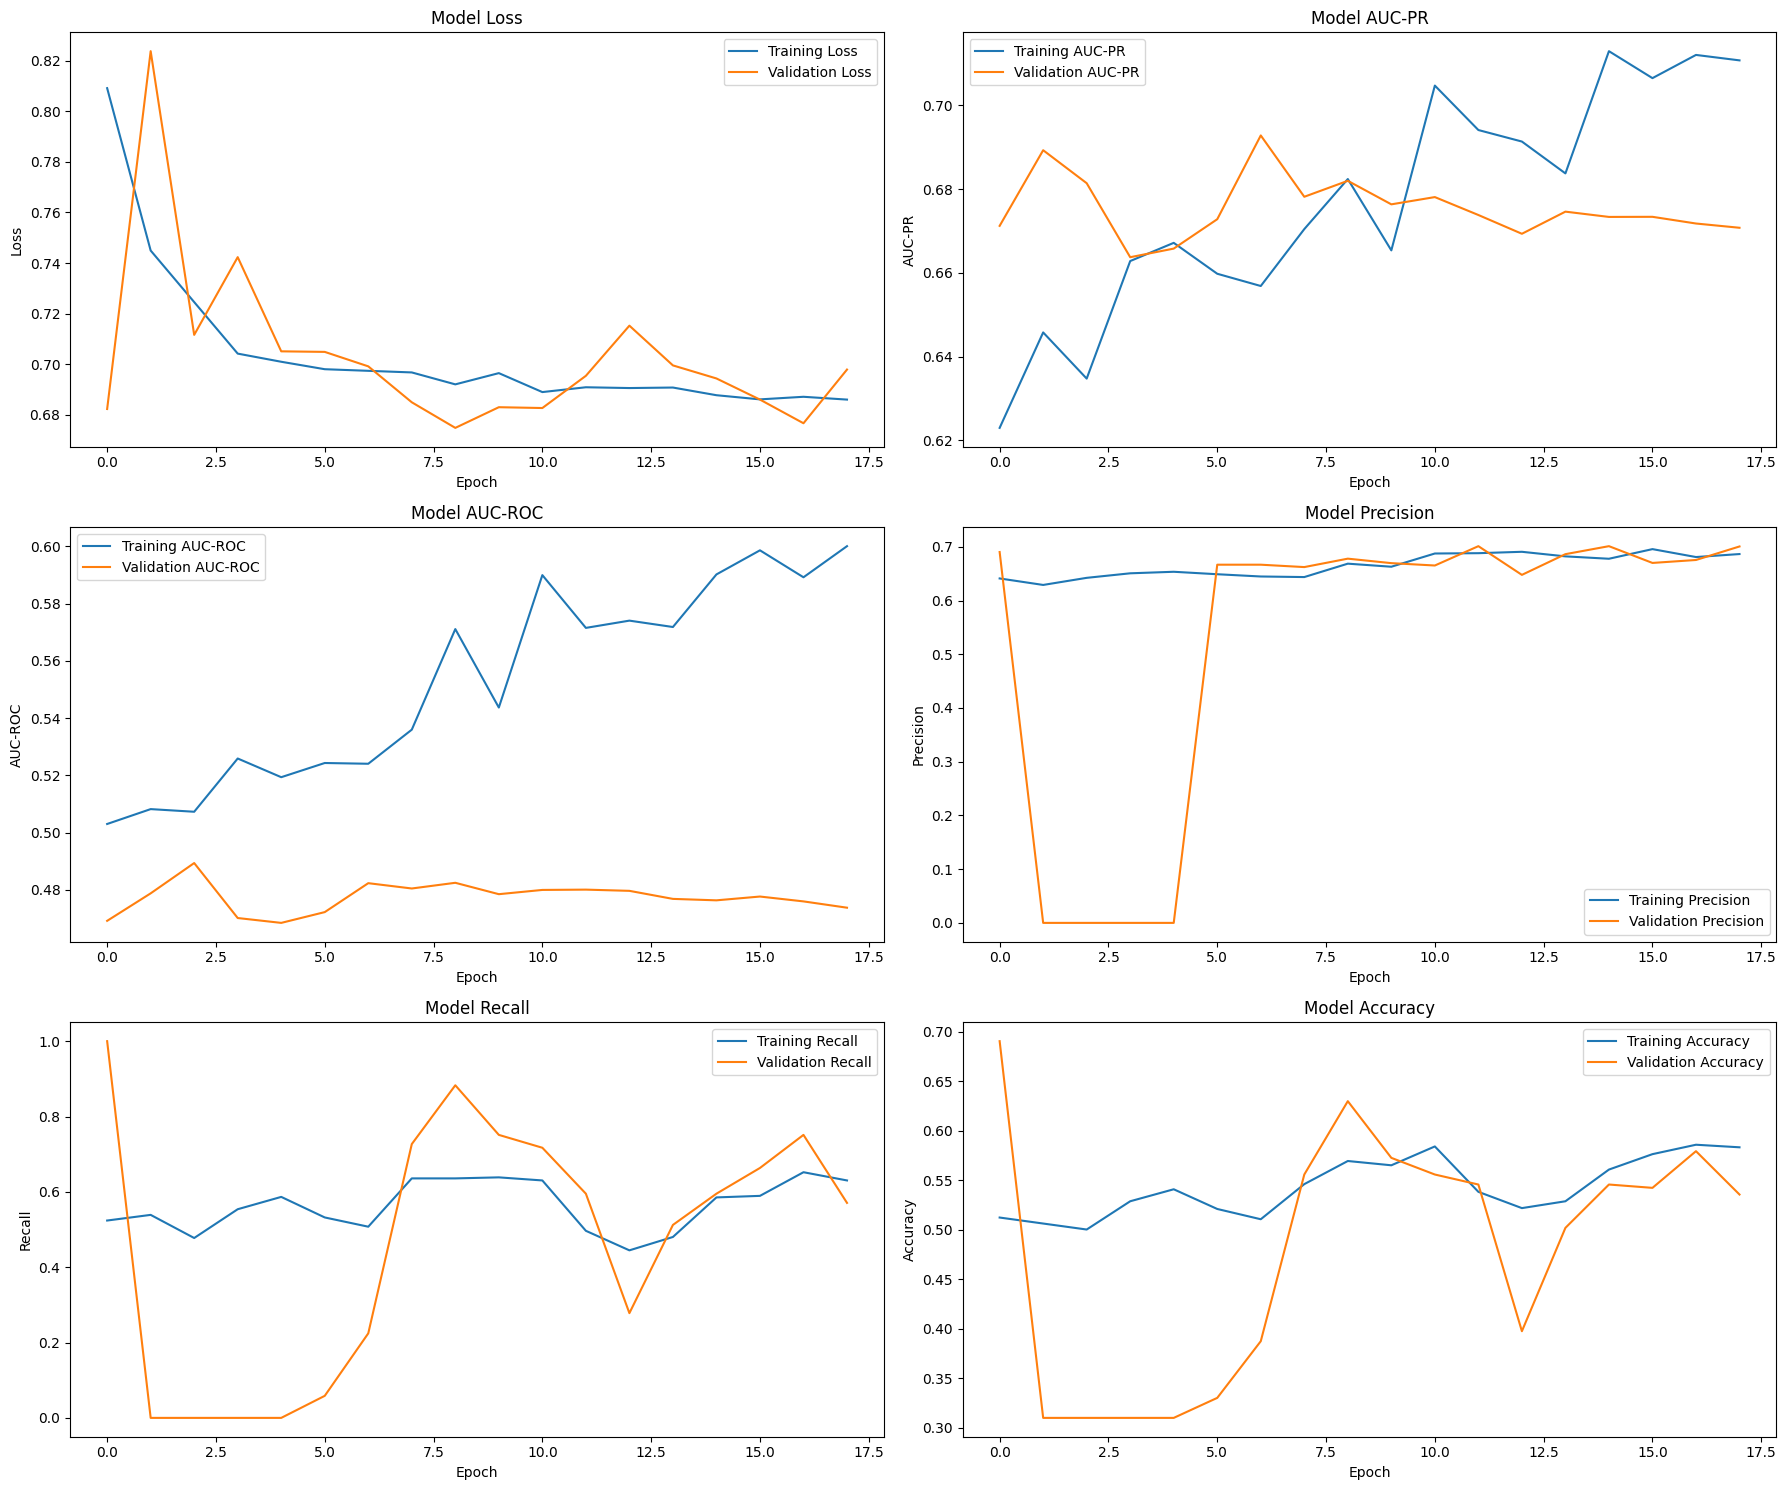

<Figure size 640x480 with 0 Axes>

In [27]:
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes[0, 0].plot(history['loss'], label='Training Loss')
axes[0, 0].plot(history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Model Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

if 'auc_pr' in history and 'val_auc_pr' in history:
    axes[0, 1].plot(history['auc_pr'], label='Training AUC-PR')
    axes[0, 1].plot(history['val_auc_pr'], label='Validation AUC-PR')
    axes[0, 1].set_title('Model AUC-PR')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('AUC-PR')
    axes[0, 1].legend()
else:
    axes[0, 1].set_visible(False)

if 'auc_roc' in history and 'val_auc_roc' in history:
    axes[1, 0].plot(history['auc_roc'], label='Training AUC-ROC')
    axes[1, 0].plot(history['val_auc_roc'], label='Validation AUC-ROC')
    axes[1, 0].set_title('Model AUC-ROC')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('AUC-ROC')
    axes[1, 0].legend()
else:
    axes[1, 0].set_visible(False)

if 'precision' in history and 'val_precision' in history:
    axes[1, 1].plot(history['precision'], label='Training Precision')
    axes[1, 1].plot(history['val_precision'], label='Validation Precision')
    axes[1, 1].set_title('Model Precision')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Precision')
    axes[1, 1].legend()
else:
    axes[1, 1].set_visible(False)

if 'recall' in history and 'val_recall' in history:
    axes[2, 0].plot(history['recall'], label='Training Recall')
    axes[2, 0].plot(history['val_recall'], label='Validation Recall')
    axes[2, 0].set_title('Model Recall')
    axes[2, 0].set_xlabel('Epoch')
    axes[2, 0].set_ylabel('Recall')
    axes[2, 0].legend()
else:
    axes[2, 0].set_visible(False)

if 'accuracy' in history and 'val_accuracy' in history:
    axes[2, 1].plot(history['accuracy'], label='Training Accuracy')
    axes[2, 1].plot(history['val_accuracy'], label='Validation Accuracy')
    axes[2, 1].set_title('Model Accuracy')
    axes[2, 1].set_xlabel('Epoch')
    axes[2, 1].set_ylabel('Accuracy')
    axes[2, 1].legend()
else:
    axes[2, 1].set_visible(False)

plt.tight_layout()
plt.show()

# Save the main plot
plt.savefig(MODEL_RESULTS_FOLDER / f'training_history.png', dpi=300, bbox_inches='tight')

In [28]:
y_pred_proba_val = model.predict(X_ts_val)
best_threshold, stats = pick_threshold(y_val, y_pred_proba_val.flatten(), method="macro")
print(f"Best threshold: {best_threshold}")
for k, v in stats.items():
    print(f"Best {k}: {v}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Best threshold: 0.47564348578453064
Best macro_f1: 0.5015000330403754


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(32, 101, 60))',)
  warnings.warn(msg)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(None, 101, 60))',)
  warnings.warn(msg)


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
MODEL EVALUATION RESULTS
=== Test Prevalence: 59.05 ===
Test AUC-PR : 0.6122
Test AUC-ROC : 0.5127
=== Threshold Dependent Metrics ===
=== Threshold: 0.48 ===
Test Accuracy : 0.5515
Test F1-Macro Score : 0.5316
Test Precision : 0.6154
Test Recall : 0.6415

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     Injured       0.62      0.64      0.63       212
 Not Injured       0.45      0.42      0.44       147

    accuracy                           0.55       359
   macro avg       0.53      0.53      0.53       359
weighted avg       0.55      0.55      0.55       359



<Figure size 640x480 with 0 Axes>

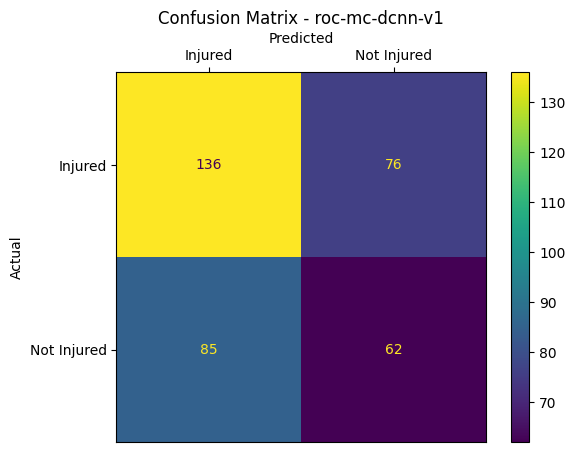

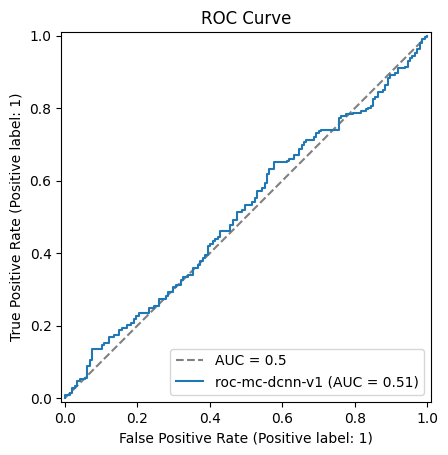

<Figure size 640x480 with 0 Axes>

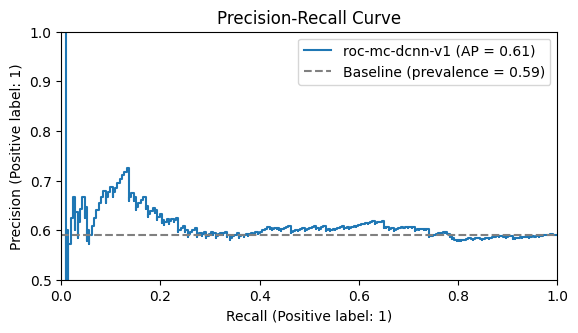

In [29]:
pred = BilateralSingleInputPredictor(model)
test_summary = model_test_summary(model, X_ts_test, y_test, threshold=best_threshold, predictor=pred)

In [30]:
# Save the trained model
if SAVE_MODEL:
    model_loader.save_keras_model_to_disk()
    
    # Save scalers for future use
    scalers = {
        'timeseries_scaler': scaler_ts,
        'metadata_scaler': scaler_meta
    }
    model_loader.save_scalers_to_disk(scalers)

    # Save training results
    results = {
        'test_accuracy': float(test_summary['accuracy']),
        'test_f1': float(test_summary['f1']),
        'tes_avg_precision': float(test_summary['auc_pr']),
        'test_auc_roc': float(test_summary['auc_roc']),
        'test_precision': float(test_summary['precision']),
        'test_recall': float(test_summary['recall']),   
        'test_prevalence': float(test_summary['prevalence']),
        'threshold': float(test_summary['threshold']),
        'model_name': MODEL_NAME,
        'training_params': {
            "epochs": model.history.params['epochs'],
            'epochs_run': len(model.history.epoch),
            'history': model.history.history,
            'batch_size': BATCH_SIZE,
            'learning_rate': float(model.optimizer.learning_rate.numpy()),
            'dropout_rate': next((layer.rate for layer in model.layers if hasattr(layer, 'rate')), "N/A"),
            'class_weights': class_weight_dict
        }
    }
    model_loader.save_results_to_disk(results)

    print(f"Model and results saved!")

Model and results saved!


## Model Explainability

Let's analyze feature importance using gradient-based saliency maps to understand which features and time points are most important for the model's predictions.


In [31]:
from core.evaluation import (
    compute_timeseries_saliency,
    plot_timeseries_saliency,
    analyze_sample_saliency,
    get_unilateral_feature_names
)

In [32]:
print("Left Side Analysis")
print("="*50)
l_feature_names = get_unilateral_feature_names(channels, side="L")
l_saliency = compute_timeseries_saliency(model, X_ts_test, method="vanilla")
l_results = analyze_sample_saliency(model, [X_ts_test], y_test, l_feature_names)

print("Right Side Analysis")
print("="*50)
r_feature_names = get_unilateral_feature_names(channels, side="R")
r_saliency = compute_timeseries_saliency(model, X_ts_test, method="vanilla")
r_results = analyze_sample_saliency(model, [X_ts_test], y_test, r_feature_names)

Left Side Analysis
Analyzing injured sample (index 2) and healthy sample (index 0)


KeyError: 'pop from an empty set'